# Glicko reads its own ratings too cautiously

This started as a different worry: that Glicko overreacts to the first game
of a season. The deviation is widest then, so game one moves a rating about
twice as far as game six does, and a week-1 squeaker over a cupcake costs a
team the same as a mid-season upset loss. The question was whether to treat a
whole season as one Glicko rating period instead.

The first-game effect turns out to be real but small. Measuring it turned up
something bigger: `glicko_full` -- the margin-scored Glicko that is ncaafb's
best single model -- is *under-confident* for most of the season, by about
five points at both ends of the scale. That is the flaw this notebook is
about; the last section is the fix, `prediction_scale`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from endgame_aws import Config

from cassandra.constants import CASSANDRA_HOME
from cassandra.predictor import load_predictor
from cassandra.save_predictions import generate_predictions, read_all_seasons

plt.style.use("ggplot")

In [2]:
league = "ncaafb"
# The same precedence `diagnose.py` uses: the latest fit on disk, else the
# checked-in search config.
generated = CASSANDRA_HOME / "models" / league
authored = Path.cwd().parent / "models" / league


def config_path(model: str) -> Path:
    fitted = generated / f"{model}_result.json"
    return fitted if fitted.exists() else authored / f"{model}.json"


seasons = [s async for s in read_all_seasons(league, Config.init_from_file().bucket)]
print(f"{len(seasons)} seasons, {min(s.year for s in seasons)}-{max(s.year for s in seasons)}")

25 seasons, 2002-2026


## Recording what each game did to a rating

`generate_predictions` is the replay every model is scored by. Wrapping the
predictor lets it run unchanged while we note, for both teams in every game,
the rating and deviation before and after, and how many games into the
season each team was. The end-of-season rating is captured at the rollover,
so a game's move can be compared with where the team finished.

In [3]:
class Recorder:
    def __init__(self, predictor):
        self._p = predictor
        self.rows = []
        self.finals = []
        self._games = {}
        self.year = None

    def __getattr__(self, name):
        return getattr(self._p, name)

    def _snapshot(self, team):
        r = self._p.get_rating(team)
        return r.rating, r.rating_deviation

    def update_game(self, game):
        pre = {t: self._snapshot(t) for t in (game.home, game.away)}
        prediction = self._p.update_game(game)
        post = {t: self._snapshot(t) for t in (game.home, game.away)}
        for t in (game.home, game.away):
            self._games[t] = self._games.get(t, 0) + 1
        home_win = game.home_score > game.away_score
        for team, is_home in ((game.home, True), (game.away, False)):
            opp = game.away if is_home else game.home
            self.rows.append(
                {
                    "year": self.year,
                    "team": team,
                    "k": self._games[team],
                    "opp_k": self._games[opp],
                    "pre": pre[team][0],
                    "pre_rd": pre[team][1],
                    "post": post[team][0],
                    "prob": prediction.team1_win_prob if is_home else 1 - prediction.team1_win_prob,
                    "won": float(home_win if is_home else not home_win),
                    "is_home": is_home,
                }
            )
        return prediction

    def pass_season(self, year=None):
        for team in self._games:
            self.finals.append({"year": self.year, "team": team, "final": self._snapshot(team)[0]})
        self._games = {}
        self.year = year
        self._p.pass_season(year)


def replay(model: str, burn_in: int = 2, **overrides) -> pd.DataFrame:
    predictor = load_predictor(config_path(model))
    if overrides:
        state = predictor.state_dict()
        state.pop("ratings")
        predictor = type(predictor)(**{**state, **overrides})
    recorder = Recorder(predictor)
    recorder.year = min(s.year for s in seasons)
    for _ in generate_predictions(recorder, seasons):
        pass
    recorder.pass_season(None)
    df = pd.DataFrame(recorder.rows).merge(pd.DataFrame(recorder.finals), on=["year", "team"])
    # The first seasons start every team at initial_rd with no history, which
    # is not what any later season looks like.
    df = df[df.year >= df.year.min() + burn_in].copy()
    df["move"] = df.post - df.pre
    df["later"] = df.final - df.post
    df["min_k"] = np.minimum(df.k, df.opp_k)
    return df


full = replay("glicko_full")
binary = replay("glicko_binary")

## The original worry: does game one teach too much?

A well-sized update is unpredictable from the updates before it -- if a
model's later moves systematically undo an earlier one, the earlier one was
too big. So for each game number `k`, regress a team's rating change from
game `k` to season's end on its move from game `k`. A slope of 0 is a
right-sized move; -0.2 means a fifth of it is later reverted.

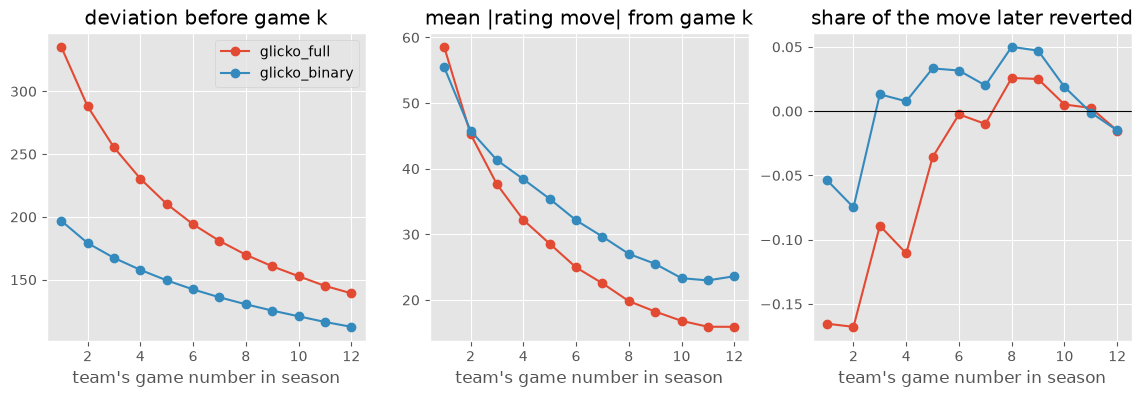

In [4]:
def by_game_number(df: pd.DataFrame, max_k: int = 12) -> pd.DataFrame:
    rows = []
    for k in range(1, max_k + 1):
        m = df[df.k == k]
        rows.append(
            {
                "k": k,
                "pre_rd": m.pre_rd.mean(),
                "abs_move": m.move.abs().mean(),
                "revert": np.polyfit(m.move, m.later, 1)[0],
            }
        )
    return pd.DataFrame(rows).set_index("k")


fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for name, df in (("glicko_full", full), ("glicko_binary", binary)):
    table = by_game_number(df)
    table.pre_rd.plot(ax=axes[0], label=name, marker="o")
    table.abs_move.plot(ax=axes[1], label=name, marker="o")
    table.revert.plot(ax=axes[2], label=name, marker="o")
axes[0].set_title("deviation before game k")
axes[1].set_title("mean |rating move| from game k")
axes[2].set_title("share of the move later reverted")
axes[2].axhline(0, color="black", linewidth=0.8)
for ax in axes:
    ax.set_xlabel("team's game number in season")
axes[0].legend();

So yes: `glicko_full` undoes about a sixth of its first two moves and a
tenth of the next two, and from game five on its updates are right-sized.
`glicko_binary` barely overreacts at all. But the overshoot is ten-odd
rating points on a 60-point move -- a percent or two of win probability on
the next game, for a third of the schedule. Worth a knob, not a rewrite.

Notice *why* the two models differ: `glicko_full` starts every season at a
deviation of 335 and `glicko_binary` at 200. The search chose that.

## The actual flaw: calibration after the first month

Brier by game number can't be compared across `k` -- the schedule mix
changes, and September is cupcakes -- but calibration can be checked within
any slice. Bin the predictions and compare the mean prediction with the
actual win rate, early in the season and after.

n  predicted  actual    gap
phase     bin                                        
games 1-4 (0.0, 0.2]   3392      0.114   0.092  0.022
          (0.2, 0.35]  3352      0.276   0.277 -0.001
          (0.35, 0.5]  3672      0.426   0.440 -0.014
          (0.5, 0.65]  4189      0.578   0.583 -0.006
          (0.65, 0.8]  4927      0.727   0.752 -0.025
          (0.8, 0.9]   3957      0.852   0.878 -0.027
          (0.9, 1.0]   4695      0.947   0.968 -0.021
games 5+  (0.0, 0.2]   5002      0.115   0.057  0.058
          (0.2, 0.35]  5798      0.277   0.222  0.055
          (0.35, 0.5]  7013      0.427   0.401  0.025
          (0.5, 0.65]  7870      0.578   0.571  0.007
          (0.65, 0.8]  8293      0.725   0.758 -0.033
          (0.8, 0.9]   5378      0.850   0.903 -0.053
          (0.9, 1.0]   4264      0.944   0.981 -0.037

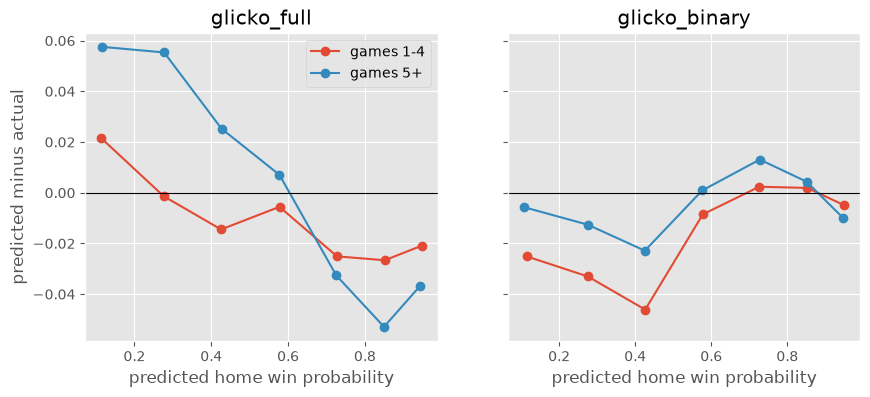

In [5]:
BINS = [0, 0.2, 0.35, 0.5, 0.65, 0.8, 0.9, 1]


def reliability(df: pd.DataFrame, prob: str = "prob") -> pd.DataFrame:
    games = df[df.is_home].copy()
    games["phase"] = np.where(games.min_k <= 4, "games 1-4", "games 5+")
    games["bin"] = pd.cut(games[prob], BINS)
    return (
        games.groupby(["phase", "bin"], observed=True)
        .agg(n=("won", "size"), predicted=(prob, "mean"), actual=("won", "mean"))
        .assign(gap=lambda x: x.predicted - x.actual)
    )


def plot_reliability(tables: dict[str, pd.DataFrame]) -> None:
    # The gap rather than the classic diagonal: on a 0-1 axis a five-point
    # miss is a hair's width, and the miss is the point.
    fig, axes = plt.subplots(1, len(tables), figsize=(5 * len(tables), 4), sharey=True)
    for ax, (name, table) in zip(np.atleast_1d(axes), tables.items()):
        for phase, rows in table.groupby(level="phase"):
            ax.plot(rows.predicted, rows.gap, marker="o", label=phase)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(name)
        ax.set_xlabel("predicted home win probability")
    np.atleast_1d(axes)[0].set_ylabel("predicted minus actual")
    np.atleast_1d(axes)[0].legend()


plot_reliability({"glicko_full": reliability(full), "glicko_binary": reliability(binary)})
reliability(full).round(3)

`glicko_binary` sits on the diagonal all season. `glicko_full` is on it for
the first four games and then falls off at both ends: it says 0.115 and the
home side wins 6% of the time, it says 0.85 and they win 90%. Every
probability past game four is pulled toward a coin flip.

### Why the margin-scored model compresses

A Glicko update moves a rating by `score - expected`, where `expected` is
the logistic of the rating gap at Elo's 400-point scale. With binary
scoring the score is the win, so the ratings settle exactly where that
logistic *is* the win probability -- the model is calibrated by
construction, which is what the right-hand panel shows.

With sigmoid scoring the score is `sigmoid(margin / sigmoid_scale)`: a
21-point win at scale 13 counts as 0.83, not 1. A team that wins every game
by three touchdowns is scored around 0.85 and so is pushed only as far from
its opponents as an 85% favorite would be. But it *wins* those games, and
the prediction reads the same gap at the same 400 and calls it 85%. The
ratings are on the margin-score's scale and the predictions read them on
the win's.

### Why it's calibrated early, and why game one overreacts

The search had one way to widen a prediction: make the ratings further
apart, and the only lever for that is the deviation. So it set
`initial_rd` to 416 and `season_rd_increase` to 287 -- a season starts
with every rating nearly as uncertain as an unrated team -- and the first
few games fling the ratings apart fast enough that September's predictions
come out about right. Then the deviations shrink, the moves get small, and
the spread settles back to what the margin score supports. That is the
pattern in both plots above, and it is one mechanism, not two.

## The fix: read the gap at its own scale

`prediction_scale` replaces the 400 in `predict_game` and nowhere else. The
update keeps Glicko's 400, so the ratings and deviations after any sequence
of games are identical whatever the scale is -- which means the sweep below
doesn't need a replay per value. The recorded probability at 400 gives the
rating gap exactly, and a different scale is a different reading of the same
gap.

at 400: 0.15699   best: 0.15614 at 340
glicko_binary, for reference: 0.16594


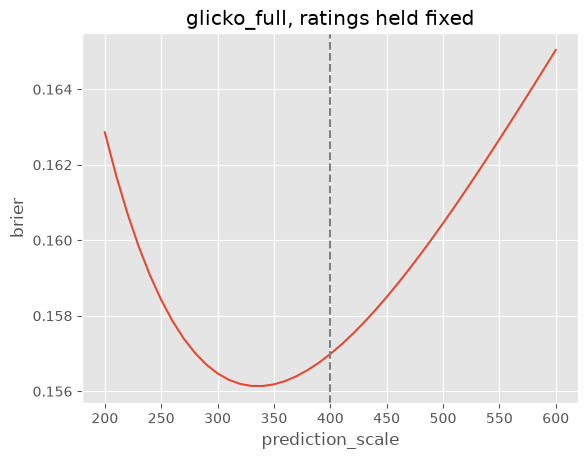

In [6]:
def rescored(df: pd.DataFrame, scale: float) -> pd.Series:
    gap = -400 * np.log10(1 / df.prob - 1)
    return 1 / (1 + 10 ** (-gap / scale))


def brier(df: pd.DataFrame, prob: pd.Series) -> float:
    games = df.is_home
    return float(((prob[games] - df.won[games]) ** 2).mean())


scales = np.arange(200, 601, 10)
sweep = pd.Series({s: brier(full, rescored(full, s)) for s in scales})
best_scale = int(sweep.idxmin())
ax = sweep.plot(xlabel="prediction_scale", ylabel="brier", title="glicko_full, ratings held fixed")
ax.axvline(400, color="grey", linestyle="--")
print(f"at 400: {sweep[400]:.5f}   best: {sweep[best_scale]:.5f} at {best_scale}")
print(f"glicko_binary, for reference: {brier(binary, binary.prob):.5f}")

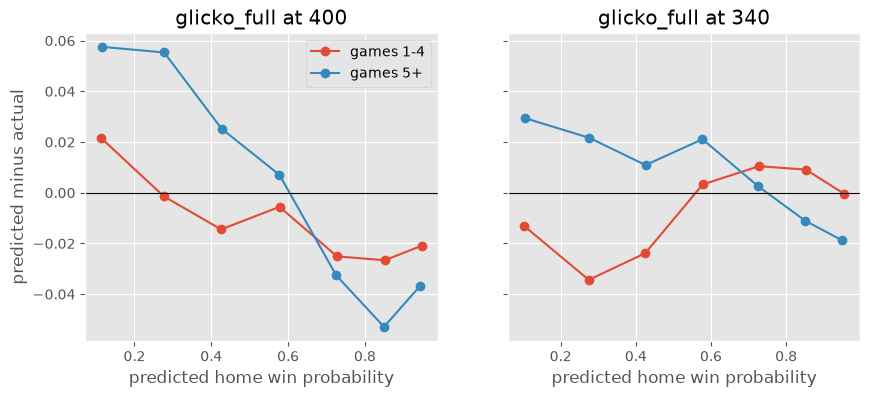

In [7]:
full["prob_scaled"] = rescored(full, best_scale)
plot_reliability(
    {
        "glicko_full at 400": reliability(full),
        f"glicko_full at {best_scale}": reliability(full, "prob_scaled"),
    }
)

The later-season gap halves and the early-season one flips sign: at a
fixed set of ratings the scale can only pick one reading, and the ratings
were fit to look right early. That is as far as the sweep can go, and it is
already worth 0.0009 of brier -- a tenth of the distance between
`glicko_full` and `glicko_binary`, and several times what any of the
matchup terms recovered.

A search that has `prediction_scale` doesn't have to inflate the deviations
to widen its predictions, so the expectation is that it brings `initial_rd`
down and the two phases meet in the middle -- which would also shrink the
first-game overshoot this started from.

In [8]:
# The offline reading is the predictor's own: a replay at the chosen scale
# lands on the same brier to the digit.
checked = replay("glicko_full", prediction_scale=best_scale)
print(f"replayed at {best_scale}: {brier(checked, checked.prob):.5f}   offline: {sweep[best_scale]:.5f}")

replayed at 340: 0.15614   offline: 0.15614


## What this means for the search

`prediction_scale` joins the `glicko_full` search in ncaafb and nfl, and
the pinned children -- `glicko_blend`, `glicko_compound` -- carry it at
400 until `sync_pins.py` moves them to whatever `glicko_full` fits. Nothing
published so far changes: a release that never named a scale replays at
400, which is the number it was always using.

The first-game overreaction is still there to look at afterwards. If the
refit leaves it, the next lever is spreading `season_rd_increase` over the
first few weeks rather than applying it all before game one.